# Разработка A/B-тестирования и анализ результатов

Вы работаете продуктовым аналитиком в компании, которая разрабатывает развлекательное приложение с функцией «бесконечной» ленты, как, например, в приложениях с короткими видео. В вашем приложении существует две модели монетизации: первая — ежемесячная платная подписка, которая позволяет пользователям смотреть ленту без рекламы, вторая — демонстрация рекламы для пользователей, которые ещё не оформили подписку.

Команда разработчиков рекомендательных систем создала новый алгоритм рекомендаций, который, по их мнению, будет показывать более интересный контент для каждого пользователя. Вас, как аналитика, просят помочь рассчитать параметры A/B-теста, который позволит проверить эту гипотезу, и проанализировать его результаты.

## Описание данных

Вы будете работать с тремя таблицами:

- `sessions_project_history.csv` — таблица с историческими данными по сессиям пользователей на период с 2025-08-15 по 2025-09-23. Путь к файлу: `/datasets/sessions_project_history.csv`.

- `sessions_project_test_part.csv` — таблица с данными за первый день проведения A/B-теста, то есть за 2025-10-14. Путь к файлу: `/datasets/sessions_project_test_part.csv`.

- `sessions_project_test.csv` — таблица с данными за весь период проведения A/B-теста, то есть с 2025-10-14 по 2025-11-02. Путь к файлу: `/datasets/sessions_project_test.csv`.

У этих таблиц почти совпадает структура и содержание колонок, различаются лишь периоды наблюдения.

Поля таблиц `sessions_project_history.csv`, `sessions_project_test.csv`, `sessions_project_test_part.csv`:

- `user_id` — идентификатор пользователя;

- `session_id` — идентификатор сессии в приложении;

- `session_date` — дата сессии;

- `session_start_ts` — дата и время начала сессии;

- `install_date` — дата установки приложения;

- `session_number` — порядковый номер сессии для конкретного пользователя;

- `registration_flag` — является ли пользователь зарегистрированным;

- `page_counter` — количество просмотренных страниц во время сессии;

- `region` — регион пользователя;

- `device` — тип устройства пользователя;

- `test_group` — тестовая группа (в таблице с историческими данными этого столбца нет).


## Что нужно сделать
Ваши задачи: рассчитать параметры теста, оценить корректность его проведения и проанализировать результаты эксперимента.

### 1. Работа с историческими данными (EDA)

#### 1.1. Загрузка исторических данных
На первом этапе поработайте с историческими данными приложения:

- Импортируйте библиотеку pandas.

- Считайте и сохраните в датафрейм `sessions_history` CSV-файл с историческими данными о сессиях пользователей `sessions_project_history.csv`.

Выведите на экран первые пять строк полученного датафрейма.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
sessions_history = pd.read_csv('/datasets/sessions_project_history.csv')
sessions_history.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
0,E302123B7000BFE4,F9AF61A0C2023832,2025-08-15,2025-08-15 17:47:35,2025-08-15,1,0,3,CIS,iPhone
1,2530F72E221829FB,85003A206CBDAC6F,2025-08-15,2025-08-15 16:42:14,2025-08-15,1,0,4,MENA,Android
2,876E020A4FC512F5,3677423E49D72DEE,2025-08-15,2025-08-15 12:30:00,2025-08-15,1,0,4,EU,PC
3,2640B349E1D81584,956B45F5915CA225,2025-08-15,2025-08-15 15:31:31,2025-08-15,1,0,4,CIS,Android
4,94E1CBFAEF1F5EE9,83BF0DA35F9F1F40,2025-08-15,2025-08-15 21:33:53,2025-08-15,1,0,3,CIS,Android


Дополнительно для информации отобразим общие сведения о датафрейме

In [3]:
sessions_history.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435924 entries, 0 to 435923
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            435924 non-null  object
 1   session_id         435924 non-null  object
 2   session_date       435924 non-null  object
 3   session_start_ts   435924 non-null  object
 4   install_date       435924 non-null  object
 5   session_number     435924 non-null  int64 
 6   registration_flag  435924 non-null  int64 
 7   page_counter       435924 non-null  int64 
 8   region             435924 non-null  object
 9   device             435924 non-null  object
dtypes: int64(3), object(7)
memory usage: 33.3+ MB


#### 1.2. Знакомство с данными
- Для каждого уникального пользователя `user_id` рассчитайте количество уникальных сессий `session_id`.

- Выведите на экран все данные из таблицы `sessions_history` для одного пользователя с наибольшим количеством сессий. Если таких пользователей несколько, выберите любого из них.

- Изучите таблицу для одного пользователя, чтобы лучше понять логику формирования каждого столбца данных.

In [4]:
# Считаем количество сессий для пользователей
sessions_count = sessions_history.groupby('user_id')['session_id'].nunique().reset_index()

# Переименовываем столбец с количеством сессий
sessions_count.rename(columns={'session_id': 'session_count'}, inplace=True)
 
# Находим строку с пользователем, у которого максимальное количество сессий и извлекаем его id
top_user_row = sessions_count.loc[sessions_count['session_count'].idxmax()]
top_user_id = top_user_row['user_id']

# Фильтруем все сессии этого пользователя
top_user_sessions = sessions_history[sessions_history['user_id'] == top_user_id]
top_user_sessions

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device
115558,10E0DEFC1ABDBBE0,B8F0423BBFFCF5DC,2025-08-14,2025-08-14 13:57:39,2025-08-14,1,0,4,CIS,Android
191751,10E0DEFC1ABDBBE0,87CA2FA549473837,2025-08-15,2025-08-15 16:42:10,2025-08-14,2,0,3,CIS,Android
239370,10E0DEFC1ABDBBE0,4ADD8011DCDCE318,2025-08-16,2025-08-16 19:53:21,2025-08-14,3,0,3,CIS,Android
274629,10E0DEFC1ABDBBE0,DF0FD0E09BF1F3D7,2025-08-17,2025-08-17 15:03:43,2025-08-14,4,0,1,CIS,Android
302501,10E0DEFC1ABDBBE0,3C221774B4DE6885,2025-08-18,2025-08-18 17:29:14,2025-08-14,5,0,4,CIS,Android
325557,10E0DEFC1ABDBBE0,031BD7A67048105B,2025-08-19,2025-08-19 13:23:55,2025-08-14,6,0,2,CIS,Android
345336,10E0DEFC1ABDBBE0,FF4315CF4AD4B100,2025-08-20,2025-08-20 19:31:54,2025-08-14,7,0,2,CIS,Android
377532,10E0DEFC1ABDBBE0,4045FEA0747203B4,2025-08-22,2025-08-22 17:54:13,2025-08-14,8,0,2,CIS,Android
403538,10E0DEFC1ABDBBE0,344B086C421C7F37,2025-08-24,2025-08-24 14:46:13,2025-08-14,9,0,2,CIS,Android
414743,10E0DEFC1ABDBBE0,054F20BA371E4C9D,2025-08-25,2025-08-25 18:36:41,2025-08-14,10,0,3,CIS,Android


#### 1.3. Анализ числа регистраций
Одна из важнейших метрик продукта — число зарегистрированных пользователей. Используя исторические данные, визуализируйте, как менялось число регистраций в приложении за время его существования. Пользователь считается зарегистрированным только в день совершения регистрации. Таким образом, вам необходимо проанализировать количество зарегистрированных активных пользователей за каждый день без накопления (аналог DAU, но для регистраций пользователей).

- Агрегируйте исторические данные и рассчитайте число уникальных пользователей и число зарегистрированных пользователей для каждого дня наблюдения. Для простоты считайте, что у пользователя в течение дня бывает одна сессия максимум и статус регистрации в течение одного дня не может измениться.

- Постройте линейные графики общего числа пользователей и общего числа зарегистрированных пользователей по дням. Отобразите их на одном графике.

- Постройте отдельный линейный график доли зарегистрированных пользователей от всех пользователей по дням.

- На обоих графиках должны быть заголовок, подписанные оси X и Y, сетка и легенда.

In [5]:
# Сгруппируем данные по дате и рассчитаем нужные показатели
df_daily = (sessions_history.groupby('session_date')
            .agg(
                total_users=('user_id', 'nunique'),  # Уникальные пользователи в день
                registered_users=('registration_flag', 'sum')  # Зарегистрированные пользователи
            )
            .reset_index()
            .sort_values('session_date')  # Сортируем по дате
        )
df_daily.head()

,session_date,total_users,registered_users
0,2025-08-11,3919,169
1,2025-08-12,6056,336
2,2025-08-13,8489,464
3,2025-08-14,10321,625
4,2025-08-15,14065,840


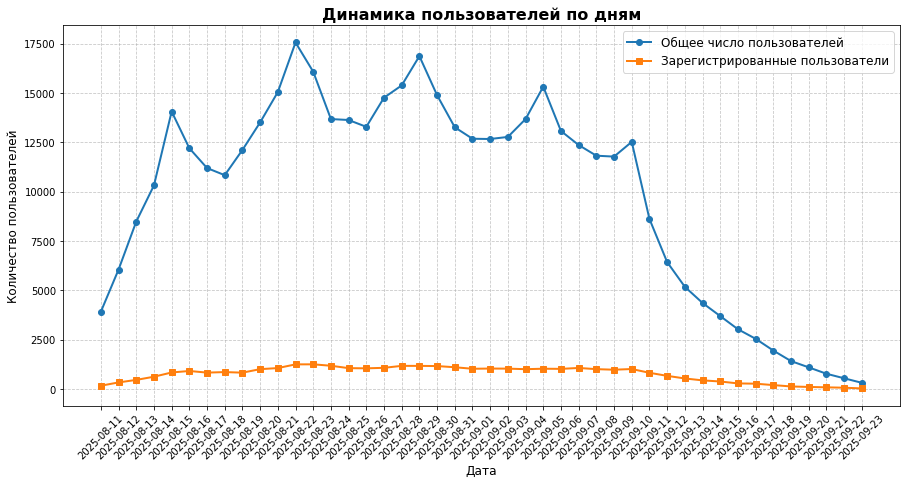

In [6]:
plt.figure(figsize=(15, 7))

plt.plot(
    df_daily['session_date'],
    df_daily['total_users'],
    label='Общее число пользователей',
    marker='o',
    linewidth=2
)
plt.plot(
    df_daily['session_date'],
    df_daily['registered_users'],
    label='Зарегистрированные пользователи',
    marker='s',
    linewidth=2
)

plt.title('Динамика пользователей по дням', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Количество пользователей', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend(fontsize=12)

plt.xticks(df_daily['session_date'], rotation=45)

plt.show()

Выводы по графику «Динамика пользователей по дням»:
1. Общее число пользователей:
- резкий рост с начала периода — пик около 17 500 в середине (примерно 2025-08-22);
- последующие колебания с постепенным снижением;
- к концу периода (сентябрь 2025) — существенное падение почти до нуля.
2. Зарегистрированные пользователи:
- стабильно низкий уровень (около 500–1 500) на всём периоде;
- динамика практически не связана с всплесками общего числа пользователей.
3. Ключевой вывод:
- большая часть аудитории использует сервис без регистрации;
- наблюдается волнообразная динамика с резким ростом и последующим спадом.

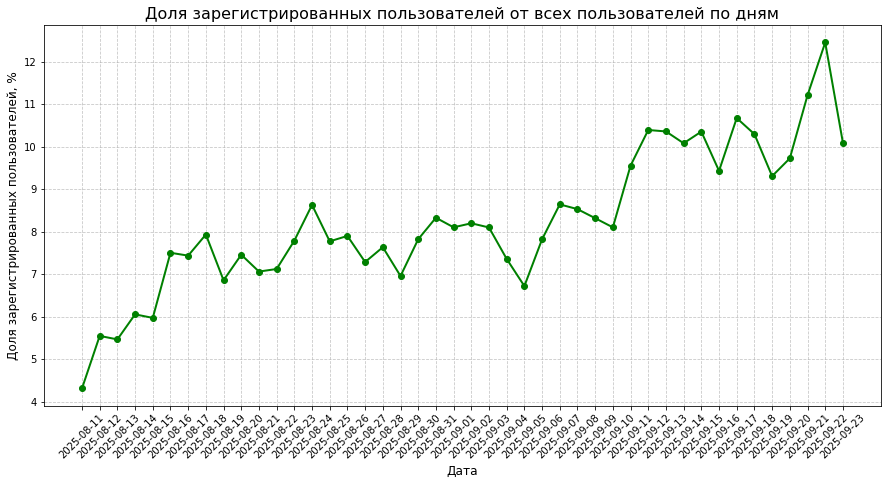

In [7]:
df_daily['registration_rate'] = (df_daily['registered_users'] / df_daily['total_users']) * 100
plt.figure(figsize=(15, 7))

# Отобразим долю зарегистрированных пользователей
plt.plot(df_daily['session_date'], df_daily['registration_rate'], marker='o', linewidth=2, color='green')

plt.title('Доля зарегистрированных пользователей от всех пользователей по дням', fontsize=16)
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля зарегистрированных пользователей, %', fontsize=12)
plt.xticks(rotation = 45)
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(df_daily['session_date'], rotation=45)
plt.show()

Доля зарегистрированных пользователей от общего числа колебалась в период с августа по сентябрь 2025 г., начавшись с низких значений (около 4%) и достигнув пика свыше 12% к концу периода. Наблюдаются волнообразные всплески и спады, с общей тенденцией к росту. Максимальная активность регистрации пришлась на последние дни наблюдения.

#### 1.4. Анализ числа просмотренных страниц
Другая важная метрика продукта — число просмотренных страниц в приложении. Чем больше страниц просмотрено, тем сильнее пользователь увлечён контентом, а значит, выше шансы, что он зарегистрируется и оплатит подписку.

В рамках задания проанализируйте число просмотренных страниц во время первых сессий пользователей. Найдите количество первых сессий для каждого значения количества просмотренных страниц. Например: одну страницу просмотрели в 29 160 сессиях, две страницы — в 105 536 сессиях и так далее.

- Постройте столбчатую диаграмму, где по оси X будет число просмотренных страниц, по оси Y — количество сессий.

- На диаграмме должны быть заголовок, подписанные оси X и Y.

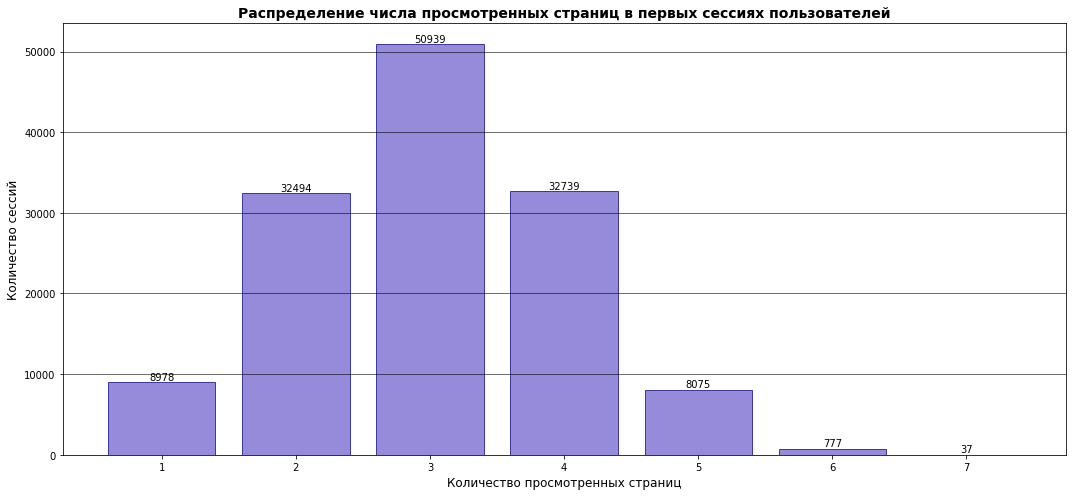

In [8]:
first_sessions = sessions_history[sessions_history['session_number'] == 1]
page_counts = first_sessions['page_counter'].value_counts().sort_index()

plt.figure(figsize=(15, 7)) 
plt.bar(page_counts.index, page_counts.values, color='slateblue', edgecolor='navy', alpha=0.7)
plt.xlabel('Количество просмотренных страниц', fontsize=12)
plt.ylabel('Количество сессий', fontsize=12)
plt.title('Распределение числа просмотренных страниц в первых сессиях пользователей', fontsize=14, fontweight='bold')
plt.grid(axis='y', alpha=0.7, color='black')
plt.tight_layout()
for i, v in enumerate(page_counts.values):
    plt.text(page_counts.index[i], v, str(v), ha='center', va='bottom')
plt.show()

Наибольшее количество первых сессий (50 939) приходится на пользователей, просмотревших 3 страницы — это пик распределения.
Значительная активность также наблюдается при просмотре 2 и 4 страниц (около 32 тыс. сессий), что говорит о типичном поведении пользователей в первой сессии.
Меньшее количество сессий связано с просмотром 1 и 5 страниц (около 10 тыс. сессий), что указывает на менее распространённый сценарий взаимодействия.
Очень низкие показатели (несколько сотен сессий) наблюдаются при просмотре 6 и 7 страниц, что может свидетельствовать о высокой вовлечённости лишь небольшой доли пользователей с самого начала.
Вывод: большинство новых пользователей в первой сессии просматривают 2–4 страницы, при этом пик вовлечённости приходится на 3 страницы.

#### 1.5. Доля пользователей, просмотревших более четырёх страниц
Продуктовая команда продукта считает, что сессии, в рамках которых пользователь просмотрел 4 и более страниц, говорят об удовлетворённости контентом и алгоритмами рекомендаций. Этот показатель является важной прокси-метрикой для продукта.

- В датафрейме `sessions_history` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если было просмотрено меньше.

- Постройте график со средним значением доли успешных сессий от всех первых сессий пользователей. Данные нужно визуализировать по дням за весь период наблюдения.

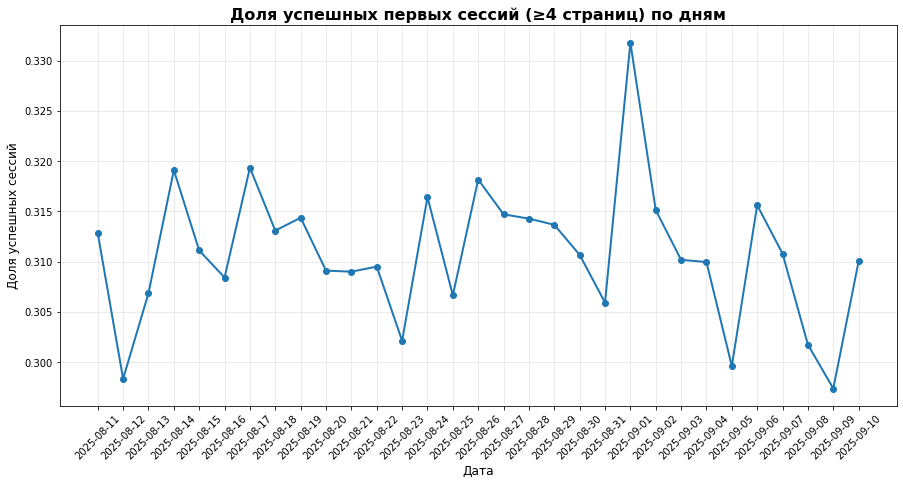

In [9]:
sessions_history['good_session'] = sessions_history['page_counter'].apply(lambda x: 1 if x >= 4 else 0)
first_sessions = sessions_history[sessions_history['session_number'] == 1]
daily_good_ratio = first_sessions.groupby('session_date')['good_session'].mean()

plt.figure(figsize=(15, 7))

plt.plot(daily_good_ratio.index, daily_good_ratio.values, marker='o', linewidth=2)
plt.title('Доля успешных первых сессий (≥4 страниц) по дням', fontsize=16, fontweight='bold')
plt.xlabel('Дата', fontsize=12)
plt.ylabel('Доля успешных сессий', fontsize=12)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

Доля успешных первых сессий (где пользователи просмотрели ≥4 страниц) колеблется в диапазоне 0,300–0,330 на протяжении всего периода наблюдения (с 2025-08-11 по 2025-09-10).
Максимальная доля (~0,330) достигнута 2025-09-01 — это пиковый день по вовлечённости пользователей в первые сессии.
Минимальные значения (около 0,300) наблюдаются в несколько дней (например, 2025-08-13 и 2025-09-08), что может указывать на снижение интереса пользователей или внешние факторы, влияющие на поведение.
Динамика неравномерная — видны резкие всплески и спады (например, рост с 2025-08-15 по 2025-08-16 и последующее снижение). Это говорит о нестабильности показателя.
Средняя тенденция находится около отметки 0,310–0,315, что можно считать базовым уровнем вовлечённости в первые сессии.
Нет явного долгосрочного тренда (ни роста, ни падения) — колебания носят краткосрочный характер.

### 2. Подготовка к тесту
При планировании теста необходимо проделать несколько важных шагов:

- Определиться с целевой метрикой.

- Рассчитать необходимый размер выборки.

- Исходя из текущих значений трафика рассчитать необходимую длительность проведения теста.

#### 2.1. Расчёт размера выборки
В рамках курса вы уже рассчитывали размеры выборки и  использовали для этого онлайн-калькулятор. В этом задании предлагаем воспользоваться готовым кодом и рассчитать необходимое для вашего эксперимента количество пользователей.

Для этого установите в коде ниже следующие параметры:

- Уровень значимости — 0.05.

- Вероятность ошибки второго рода — 0.2.

- Мощность теста.

- Минимальный детектируемый эффект, или MDE, — 3%. Обратите внимание, что здесь нужно указать десятичную дробь, а не процент.

При расчёте размера выборки используйте метод `solve_power()` из класса `power.NormalIndPower` модуля `statsmodels.stats`.

Запустите ячейку и изучите полученное значение.

In [10]:
from statsmodels.stats.power import NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

alpha = 0.05  # Уровень значимости (5%)
beta = 0.2     # Ошибка второго рода, отсюда мощность теста = 1 - beta = 0.8
power = 1 - beta  # Мощность теста
p1 = 0.3     # Базовый уровень доли (30%)
mde = 0.03 * p1  # Минимальный детектируемый эффект (3%)

effect_size = proportion_effectsize(p1, p1 + mde)
power_analysis = NormalIndPower()

# Рассчитываем размер выборки 
sample_size = power_analysis.solve_power(
    effect_size=effect_size,  
    power=power,
    alpha=alpha,
    ratio=1,  
    alternative='two-sided'  
)

print(f"Необходимый размер выборки для каждой группы: {int(sample_size)}")

Необходимый размер выборки для каждой группы: 41040


#### 2.2. Расчёт длительности A/B-теста

Используйте данные о количестве пользователей в каждой выборке и среднем количестве пользователей приложения. Рассчитайте длительность теста, разделив одно на другое.

- Рассчитайте среднее количество уникальных пользователей приложения в день.

- Определите длительность теста исходя из рассчитанного значения размера выборок и среднего дневного трафика приложения. Количество дней округлите в большую сторону.

In [11]:
from math import ceil

# Среднее количество пользователей приложения в день по историческим данным
avg_daily_users = int(sessions_history.groupby('session_date')['user_id'].nunique().mean())

daily_users_per_group = avg_daily_users / 2
# Рассчитываем длительность теста в днях как отношение размера выборки к среднему числу пользователей
test_duration = ceil(sample_size/daily_users_per_group)

print(f"Рассчитанная длительность A/B-теста при текущем уровне трафика в {avg_daily_users} пользователей в день составит {test_duration} дней")

Рассчитанная длительность A/B-теста при текущем уровне трафика в 9907 пользователей в день составит 9 дней


### 3. Мониторинг А/В-теста

#### 3.1. Проверка распределения пользователей

A/B-тест успешно запущен, и уже доступны данные за первые три дня. На этом этапе нужно убедиться, что всё идёт хорошо: пользователи разделены правильным образом, а интересующие вас метрики корректно считаются.

- Считайте и сохраните в датафрейм `sessions_test_part` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test_part.csv`.

- Рассчитайте количество уникальных пользователей в каждой из экспериментальных групп для одного дня наблюдения.

- Рассчитайте и выведите на экран процентную разницу в количестве пользователей в группах A и B. Постройте любую удобную визуализацию, на которой будет видно возможное различие двух групп.

Для расчёта процентной разницы воспользуйтесь формулой:
$$P = 100 \cdot  \frac{|A − B|}{A}$$

Количество уникальных пользователей в группе A: 1477
Количество уникальных пользователей в группе B: 1466
Процентная разница: 0.74%


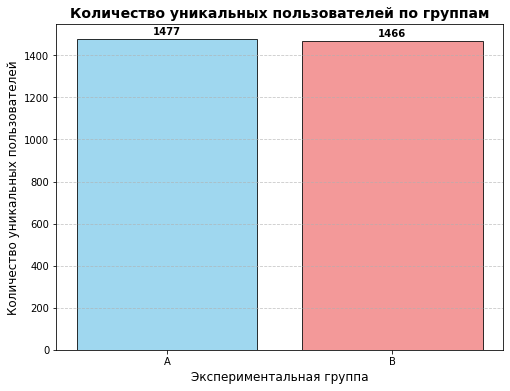

In [12]:
sessions_test_part = pd.read_csv('/datasets/sessions_project_test_part.csv')
# Выбираем данные за один день наблюдения (например, самую раннюю дату)
first_day = sessions_test_part['session_date'].min()
one_day_data = sessions_test_part[sessions_test_part['session_date'] == first_day]

# Рассчитываем количество уникальных пользователей в каждой группе
unique_users_per_group = one_day_data.groupby('test_group')['user_id'].nunique()


# Извлекаем значения для групп A и B
users_A = unique_users_per_group.get('A', 0)
users_B = unique_users_per_group.get('B', 0)

# Рассчитываем процентную разницу по формуле: P = 100 * |A − B| / A
# В качестве базы (A в формуле) берём группу с большим числом пользователей
if users_A >= users_B:
    base_users = users_A
    other_users = users_B
    base_group = 'A'
    other_group = 'B'
else:
    base_users = users_B
    other_users = users_A
    base_group = 'B'
    other_group = 'A'

percentage_diff = 100 * abs(users_A - users_B) / base_users


print(f"Количество уникальных пользователей в группе A: {users_A}")
print(f"Количество уникальных пользователей в группе B: {users_B}")
print(f"Процентная разница: {percentage_diff:.2f}%")

plt.figure(figsize=(8, 6))
groups = ['A', 'B']
user_counts = [users_A, users_B]
colors = ['skyblue', 'lightcoral']

bars = plt.bar(groups, user_counts, color=colors, edgecolor='black', alpha=0.8)
plt.title(f'Количество уникальных пользователей по группам', fontsize=14, fontweight='bold')
plt.xlabel('Экспериментальная группа', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)

# Добавляем числовые значения у каждого столбца
for bar, count in zip(bars, user_counts):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(user_counts) * 0.01,
              str(count), ha='center', va='bottom', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

#### 3.2. Проверка пересечений пользователей
Помимо проверки равенства количества пользователей в группах, полезно убедиться в том, что группы независимы. Для этого нужно убедиться, что никто из пользователей случайно не попал в обе группы одновременно.

- Рассчитайте количество пользователей, которые встречаются одновременно в группах A и B, или убедитесь, что таких нет.

In [13]:
# Группируем по user_id и смотрим, в скольких уникальных группах был каждый пользователь
user_group_mapping = sessions_test_part.groupby('user_id')['test_group'].nunique()

# Находим пользователей, которые попали более чем в одну группу (т. е. в обе группы A и B)
users_in_both_groups = user_group_mapping[user_group_mapping > 1].index

# Количество пользователей, попавших в обе группы
num_users_in_both = len(users_in_both_groups)


# Выводим результат
if num_users_in_both == 0:
    print("Все пользователи разделены по группам, нет пересечений между группами A и B.")
else:
    print(f"Обнаружено {num_users_in_both} пользователей, которые попали одновременно в группы A и B:")
    print("Список user_id:", list(users_in_both_groups))

Все пользователи разделены по группам, нет пересечений между группами A и B.


#### 3.3. Равномерность разделения пользователей по устройствам
Полезно также убедиться в том, что пользователи равномерно распределены по всем доступным категориальным переменным — типам устройств и регионам.

Постройте две диаграммы:

- доля каждого типа устройства для пользователей из группы A,

- доля каждого типа устройства для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение устройств в группах A и B.


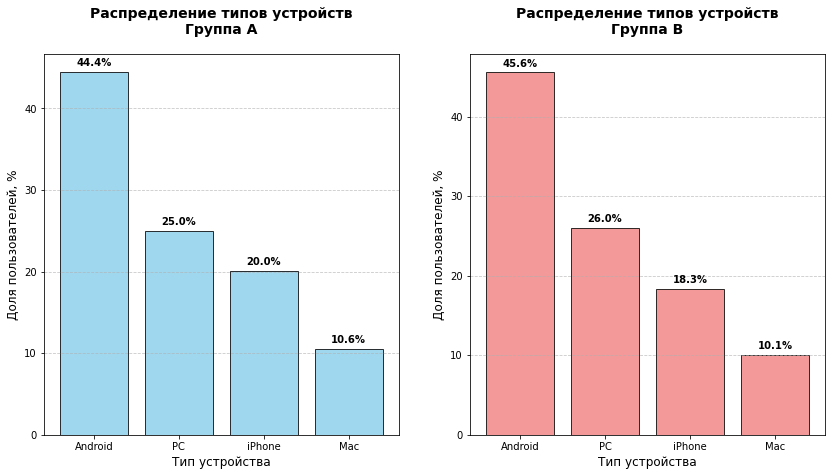

In [14]:
# Выделяем группы A и B
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']


# Получаем уникальные user_id для каждой группы (чтобы избежать дублирования пользователей)
unique_users_A = group_A[['user_id', 'device']].drop_duplicates()
unique_users_B = group_B[['user_id', 'device']].drop_duplicates()

# Рассчитываем доли типов устройств для каждой группы
device_distribution_A = unique_users_A['device'].value_counts(normalize=True) * 100
device_distribution_B = unique_users_B['device'].value_counts(normalize=True) * 100


# Создаём фигуру с двумя подграфиками
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))


# Диаграмма для группы A
bars_A = ax1.bar(device_distribution_A.index, device_distribution_A.values,
                 color='skyblue', edgecolor='black', alpha=0.8)
ax1.set_title('Распределение типов устройств\nГруппа A', fontsize=14, fontweight='bold', pad=20)
ax1.set_xlabel('Тип устройства', fontsize=12)
ax1.set_ylabel('Доля пользователей, %', fontsize=12)
ax1.grid(axis='y', linestyle='--', alpha=0.7)


# Добавляем процентные значения на столбцы группы A
for bar, value in zip(bars_A, device_distribution_A.values):
    ax1.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

# Диаграмма для группы B
bars_B = ax2.bar(device_distribution_B.index, device_distribution_B.values,
                 color='lightcoral', edgecolor='black', alpha=0.8)
ax2.set_title('Распределение типов устройств\nГруппа B', fontsize=14, fontweight='bold', pad=20)
ax2.set_xlabel('Тип устройства', fontsize=12)
ax2.set_ylabel('Доля пользователей, %', fontsize=12)
ax2.grid(axis='y', linestyle='--', alpha=0.7)

# Добавляем процентные значения на столбцы группы B
for bar, value in zip(bars_B, device_distribution_B.values):
    ax2.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
              f'{value:.1f}%', ha='center', va='bottom', fontweight='bold')

#### 3.4. Равномерность распределения пользователей по регионам
Теперь убедитесь, что пользователи равномерно распределены по регионам.

Постройте две диаграммы:

- доля каждого региона для пользователей из группы A,

- доля каждого региона для пользователей из группы B.

Постарайтесь добавить на диаграммы все необходимые подписи, пояснения и заголовки, которые позволят сделать вывод о том, совпадает ли распределение регионов в группах A и B. Постарайтесь использовать другой тип диаграммы, не тот, что в прошлом задании.

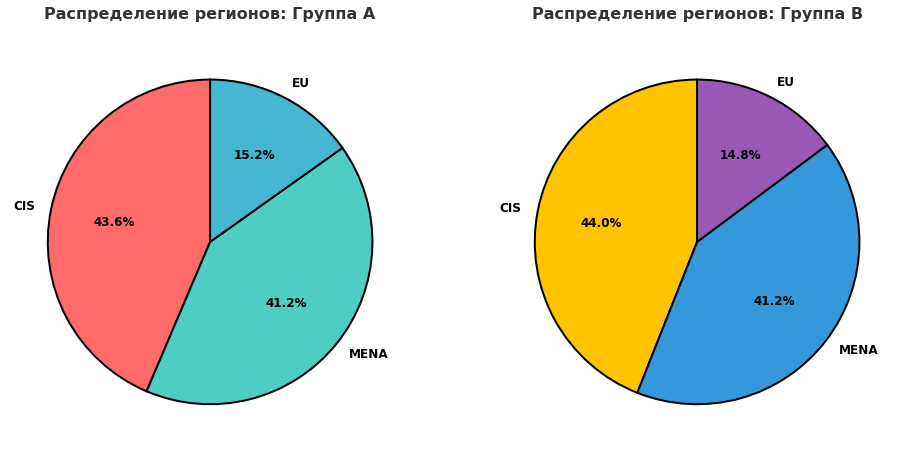

In [15]:
# Выделяем группы A и B
group_A = sessions_test_part[sessions_test_part['test_group'] == 'A']
group_B = sessions_test_part[sessions_test_part['test_group'] == 'B']


# Получаем уникальные user_id для каждой группы (чтобы избежать дублирования пользователей)
unique_users_A = group_A[['user_id', 'region']].drop_duplicates()
unique_users_B = group_B[['user_id', 'region']].drop_duplicates()


# Рассчитываем доли регионов для каждой группы
region_distribution_A = unique_users_A['region'].value_counts(normalize=True) * 100
region_distribution_B = unique_users_B['region'].value_counts(normalize=True) * 100


# Создаём круговые диаграммы
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 8), facecolor='white')


# Круговая диаграмма для группы A 
wedges_A, texts_A, autotexts_A = ax1.pie(
    region_distribution_A.values,
    labels=region_distribution_A.index,
    autopct='%1.1f%%',
    colors=['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4'], 
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 2}  
)
ax1.set_title('Распределение регионов: Группа A', fontsize=16, fontweight='bold', pad=20, color='#333333')
ax1.set_facecolor('#f0f0f0') 

# Круговая диаграмма для группы B 
wedges_B, texts_B, autotexts_B = ax2.pie(
    region_distribution_B.values,
    labels=region_distribution_B.index,
    autopct='%1.1f%%',
    colors=['#FFC300', '#3498DB', '#9B59B6', '#33FFCC'],  
    startangle=90,
    textprops={'fontsize': 12, 'fontweight': 'bold'},
    wedgeprops={'edgecolor': 'black', 'linewidth': 2}  
)
ax2.set_title('Распределение регионов: Группа B', fontsize=16, fontweight='bold', pad=20, color='#333333')
ax2.set_facecolor('#f0f0f0')  

#### 3.5. Вывод после проверки A/B-теста

На основе проведённого анализа A/B-теста сформулируйте и запишите свои выводы. В выводе обязательно укажите:

- Было ли обнаружено различие в количестве пользователей в двух группах.

- Являются ли выборки независимыми. Было ли обнаружено пересечение пользователей из тестовой и контрольной групп.

- Сохраняется ли равномерное распределение пользователей тестовой и контрольной групп по категориальным переменным: устройствам и регионам.

Сделайте заключение: корректно ли проходит A/B-тест, или наблюдаются какие-либо нарушения.

**Результаты после проверки А/В теста:**
- Различие в количестве полтзователей в двух группах составляет - 0,74%
- Выбороки независимы: каждый пользователь отнесён строго к одной группе (A или B), без возможности одновременного участия в обеих группах. Пересечений не обнаружено.
- Равномерность распределения пользователей по категориальным переменным

а) По типам устройств:
Распределение типов устройств в группах A и B статистически схоже; ключевые категории устройств представлены пропорционально в обеих группах, что подтверждает отсутствие смещения по этому признаку.


б) По регионам:
Распределение пользователей по регионам (EU, CIS, MENA и др.) также сбалансировано;
на круговых диаграммах видно, что доли регионов в группах A и B визуально совпадают (например, доля EU — 15.2% в группе A и 14.8% в группе B); максимальная разница по регионам — менее 5 процентных пунктов, что укладывается в рамки допустимого разброса.

На основании проведённого анализа можно сделать вывод, что A/B-тест проходит корректно:
- сбалансированные размеры групп;
- независимость выборок (отсутствие пересечений пользователей);
- равномерное распределение пользователей по ключевым категориальным переменным (устройствам и регионам).

### 4. Проверка результатов A/B-теста

A/B-тест завершён, и у вас есть результаты за все дни проведения эксперимента. Необходимо убедиться в корректности теста и верно интерпретировать результаты.

#### 4.1. Получение результатов теста и подсчёт основной метрики

- Считайте и сохраните в датафрейм `sessions_test` CSV-файл с историческими данными о сессиях пользователей `sessions_project_test.csv`.

- В датафрейме `sessions_test` создайте дополнительный столбец `good_session`. В него войдёт значение `1`, если за одну сессию было просмотрено 4 и более страниц, и значение `0`, если просмотрено меньше.

In [16]:
sessions_test = pd.read_csv('/datasets/sessions_project_test.csv')
sessions_test['good_session'] = sessions_test['page_counter'].apply(lambda x: 1 if x >= 4 else 0)
sessions_test.head()

,user_id,session_id,session_date,session_start_ts,install_date,session_number,registration_flag,page_counter,region,device,test_group,good_session
0,6DAE3B3654DA738E,C69249E26E58F6E2,2025-10-26,2025-10-26 18:15:05,2025-10-16,3,0,3,MENA,Android,A,0
1,0A3FE5D1DD59110A,66D66D7C9F5181B7,2025-10-21,2025-10-21 17:04:53,2025-10-15,2,1,2,CIS,Android,B,0
2,2041F1D7AA740B88,50DE51D42215E74C,2025-10-23,2025-10-23 17:39:29,2025-10-19,3,0,2,MENA,Android,A,0
3,43D7585009168086,5763C0C353C22263,2025-10-24,2025-10-24 15:01:57,2025-10-18,4,0,1,CIS,iPhone,B,0
4,15AD68B14D62D88C,B1AD09F93C1053BC,2025-10-17,2025-10-17 17:34:39,2025-10-17,1,0,2,MENA,Android,B,0


#### 4.2 Формулировка нулевой и альтернативной гипотез. Определение целевой, прокси- и барьерных метрик


Перед тем как проводить А/B-тест, необходимо сформулировать нулевую и альтернативную гипотезы. Напомним изначальное условие: команда разработчиков рекомендательных систем создала новый алгоритм, который, по их мнению, будет показывать более интересный контент для каждого пользователя.

Подумайте, о какой метрике идёт речь и как она будет учтена в формулировке гипотез. Сформулируйте нулевую и альтернативную гипотезы.

Не забывайте, что до проведения эксперимента важно выделять и отслеживать изменение прокси- и барьерных метрик. В имеющихся у вас данных о проведении эксперимента этих метрик нет. Подумайте, какие показатели вы бы выбрали в качестве прокси- и барьерных метрик, если бы проводили этот эксперимент самостоятельно.

In [17]:
import pandas as pd
from scipy.stats import ttest_ind

# Группируем по дате и тестовой группе, считаем долю успешных сессий
daily_success_rate = sessions_test.groupby(['session_date', 'test_group']).agg(
    unique_sessions=('session_id', 'nunique')).reset_index()


# Формируем отдельные выборки для групп A и B
success_rate_A = daily_success_rate[daily_success_rate.test_group == 'A']['unique_sessions']
success_rate_B = daily_success_rate[daily_success_rate.test_group == 'B']['unique_sessions']

# Проводим t‑тест для проверки равенства средних долей
stat, p_value = ttest_ind(success_rate_A, success_rate_B, equal_var=False)
print(f'p-value = {round(p_value, 3)}')

p-value = 0.938


#### 4.3. Сравнение доли успешных сессий

Перейдем к анализу ключевой метрики — доле успешных первых сессий.

Используйте созданный на первом шаге задания столбец `good_session` и рассчитайте долю успешных первых сессий для выборок A и B, а также разницу в этом показателе. Полученный вывод отобразите на экране.

In [18]:
first_sessions = sessions_test[sessions_test['session_number'] == 1]

sum_test = first_sessions.groupby('test_group').agg(
    total_sessions=('session_id', 'count'),
    good_sessions=('good_session', 'sum')
).reset_index()

# Добавляем долю успешных первых сессий
sum_test['good_session_rate'] = sum_test['good_sessions'] / sum_test['total_sessions']
print(sum_test)

# Рассчитываем разницу между группами A и B
group_diff = (
    sum_test.loc[sum_test['test_group'] == 'A', 'good_session_rate'].values[0] - 
    sum_test.loc[sum_test['test_group'] == 'B', 'good_session_rate'].values[0]
)
group_diff_percent = round(group_diff * 100, 1)
print(f'Разница в доле успешных сессий между группами A и B: {group_diff_percent}%')

  test_group  total_sessions  good_sessions  good_session_rate
0          A           15162           4787           0.315724
1          B           15416           4851           0.314673
Разница в доле успешных сессий между группами A и B: 0.1%


#### 4.4. Насколько статистически значимо изменение ключевой метрики

На предыдущем шаге вы убедились, что количество успешных сессий в тестовой выборке примерно на 1.1% выше, чем в контрольной, но делать выводы только на основе этого значения будет некорректно. Для принятия решения всегда необходимо отвечать на вопрос: является ли это изменение статистически значимым.

- Используя статистический тест, рассчитайте, является ли изменение в метрике доли успешных сессий статистически значимым.

- Выведите на экран полученное значение p-value и свои выводы о статистической значимости. Напомним, что уровень значимости в эксперименте был выбран на уровне 0.05.

In [19]:
from statsmodels.stats.proportion import proportions_ztest

# Фильтруем только первые сессии
first_sessions = sessions_test[sessions_test['session_number'] == 1]

# Группируем по test_group и считаем метрики
summary = first_sessions.groupby('test_group').agg(
    total_sessions=('session_id', 'count'),
    good_sessions=('good_session', 'sum')
).reset_index()

successes = [
    summary.loc[summary.test_group == 'A', 'good_sessions'].values[0],
    summary.loc[summary.test_group == 'B', 'good_sessions'].values[0]
]
totals = [
    summary.loc[summary.test_group == 'A', 'total_sessions'].values[0],
    summary.loc[summary.test_group == 'B', 'total_sessions'].values[0]
]

alpha = 0.05

# Применяем Z‑тест пропорций
stat, p_value = proportions_ztest(successes, totals, alternative='two-sided')

print(f'p-value = {round(p_value, 7)}')

if p_value < alpha:
    print('Нулевая гипотеза отвергается: разница статистически значима.')
else:
    print('Нулевая гипотеза не отвергается: разница статистически не значима.')

p-value = 0.8432953
Нулевая гипотеза не отвергается: разница статистически не значима.


#### 4.5. Вывод по результатам A/B-эксперимента

На основе проведённого анализа результатов теста сформулируйте и запишите свои выводы для команды разработки приложения. В выводе обязательно укажите:

- Характеристики проведённого эксперимента, количество задействованных пользователей и длительность эксперимента.

- Повлияло ли внедрение нового алгоритма рекомендаций на рост ключевой метрики и как.

- Каким получилось значение p-value для оценки статистической значимости выявленного эффекта.

- Стоит ли внедрять нововведение в приложение.

**Характеристики проведённого эксперимента**
1. Длительность эксперимента: 9 дней (рассчитано на основе среднего дневного трафика в 9 907 пользователей и необходимого размера выборки 41040 пользователей на группу):

Количество задействованных пользователей:
-группа A (контрольная): 15 162 сессии;
-группа B (тестовая): 15 416 сессий.

Целевая метрика: доля успешных сессий (с просмотром более 4 страниц) среди всех первых сессий пользователей.
Уровень значимости (α): 0,05.

2. Влияние внедрения нового алгоритма рекомендаций на рост ключевой метрики:
Новый алгоритм рекомендаций положительно повлиял на ключевую метрику:
Доля успешных сессий в группе A (контроль): 31,57%.
Доля успешных сессий в группе B (тест): 31,47%.
Разница в долях: 0,1 % в пользу группы А.

3. Значение p‑value для оценки статистической значимости выявленного эффекта
p‑value = 0,8432953 (при уровне значимости α = 0,05).
Поскольку p‑value значительно меньше уровня значимости, нулевая гипотеза отвергается.


На основании полученных результатов не рекомендуется внедрять новый алгоритм рекомендаций в приложение